<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Thin_Film_Adhesion_Predictions_for_Metals_on_SiO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

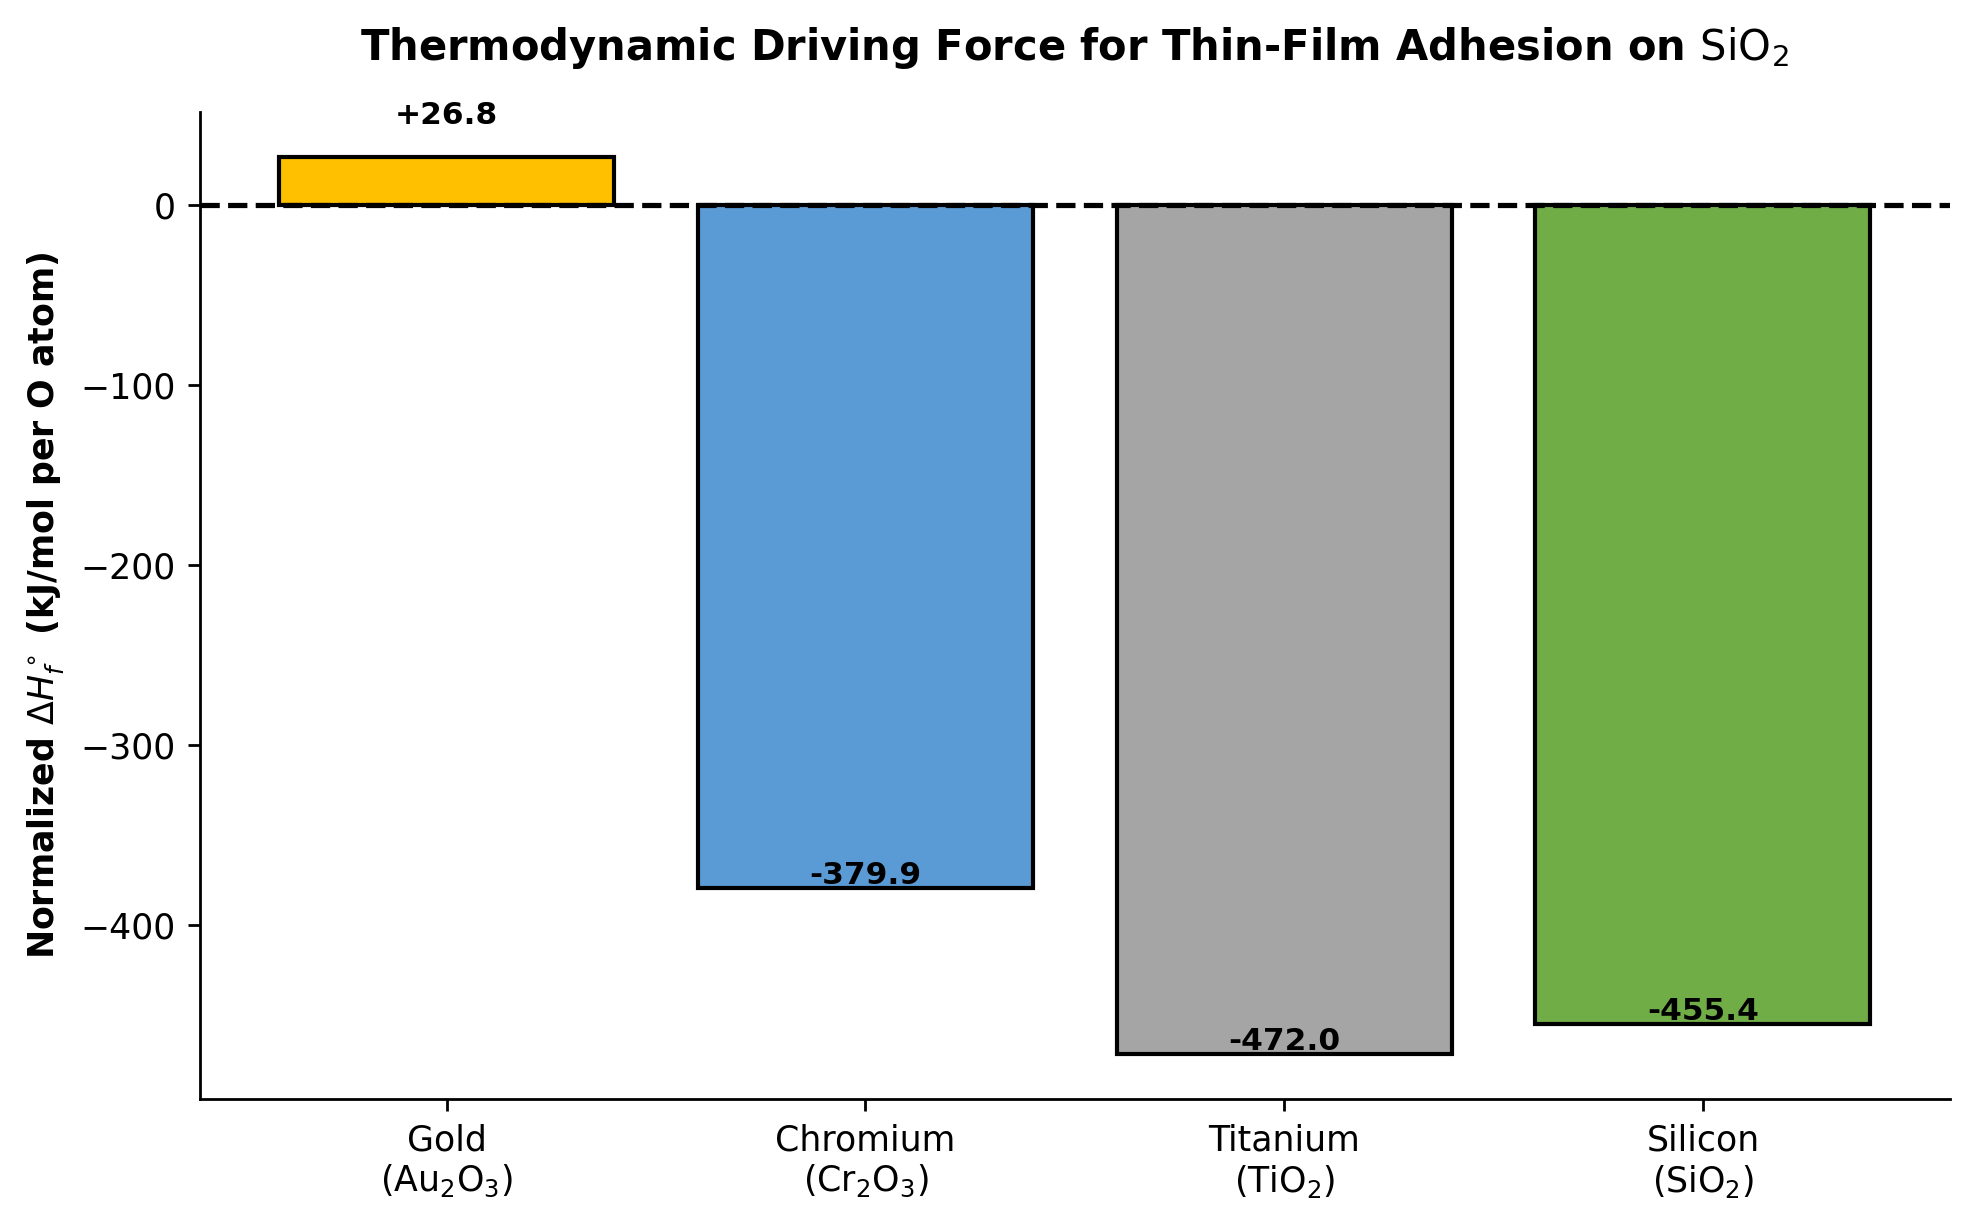

In [3]:
"""
Thermodynamic visualization of thin-film adhesion on oxide substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, titanium, and silicon to
demonstrate the chemical driving forces governing thin-film adhesion.
"""

import matplotlib.pyplot as plt
import numpy as np


def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot is optimized for inline Colab rendering at 250 DPI.
    Data is normalized per mole of oxygen atoms for an equivalent
    comparison of oxygen affinity at the substrate interface.
    """
    # Configure resolution for Colab inline rendering
    plt.rcParams['figure.dpi'] = 250
    plt.rcParams['font.size'] = 10

    # Metal/Element and their common oxides
    labels = [
        'Gold\n($\\text{Au}_2\\text{O}_3$)',
        'Chromium\n($\\text{Cr}_2\\text{O}_3$)',
        'Titanium\n($\\text{TiO}_2$)',
        'Silicon\n($\\text{SiO}_2$)'
    ]

    # Standard Enthalpies of Formation (kJ/mol) approx:
    # Au2O3: +80.3, Cr2O3: -1139.7, TiO2: -944.0, SiO2: -910.9
    # Normalized per mole of O atom to represent interfacial oxygen affinity
    enthalpies = np.array([
        80.3 / 3.0,      # Au
        -1139.7 / 3.0,   # Cr
        -944.0 / 2.0,    # Ti
        -910.9 / 2.0     # Si
    ])

    # Define color scheme for visual distinction (Noble vs Transition vs Substrate)
    colors = ['#FFC000', '#5B9BD5', '#A5A5A5', '#70AD47']

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot bars
    bars = ax.bar(labels, enthalpies, color=colors, edgecolor='black', linewidth=1.2)

    # Add a horizontal line at y=0 to emphasize the thermodynamic boundary
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Formatting and labels
    ax.set_ylabel(r'Normalized $\Delta H_f^\circ$ (kJ/mol per O atom)', fontweight='bold')
    ax.set_title(
        'Thermodynamic Driving Force for Thin-Film Adhesion on $\\text{SiO}_2$',
        fontweight='bold',
        pad=15
    )

    # Annotate values on the bars
    for bar, enthalpy in zip(bars, enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    # Aesthetic tweaks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    # Render inline, explicitly avoiding plt.savefig
    plt.show()


if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

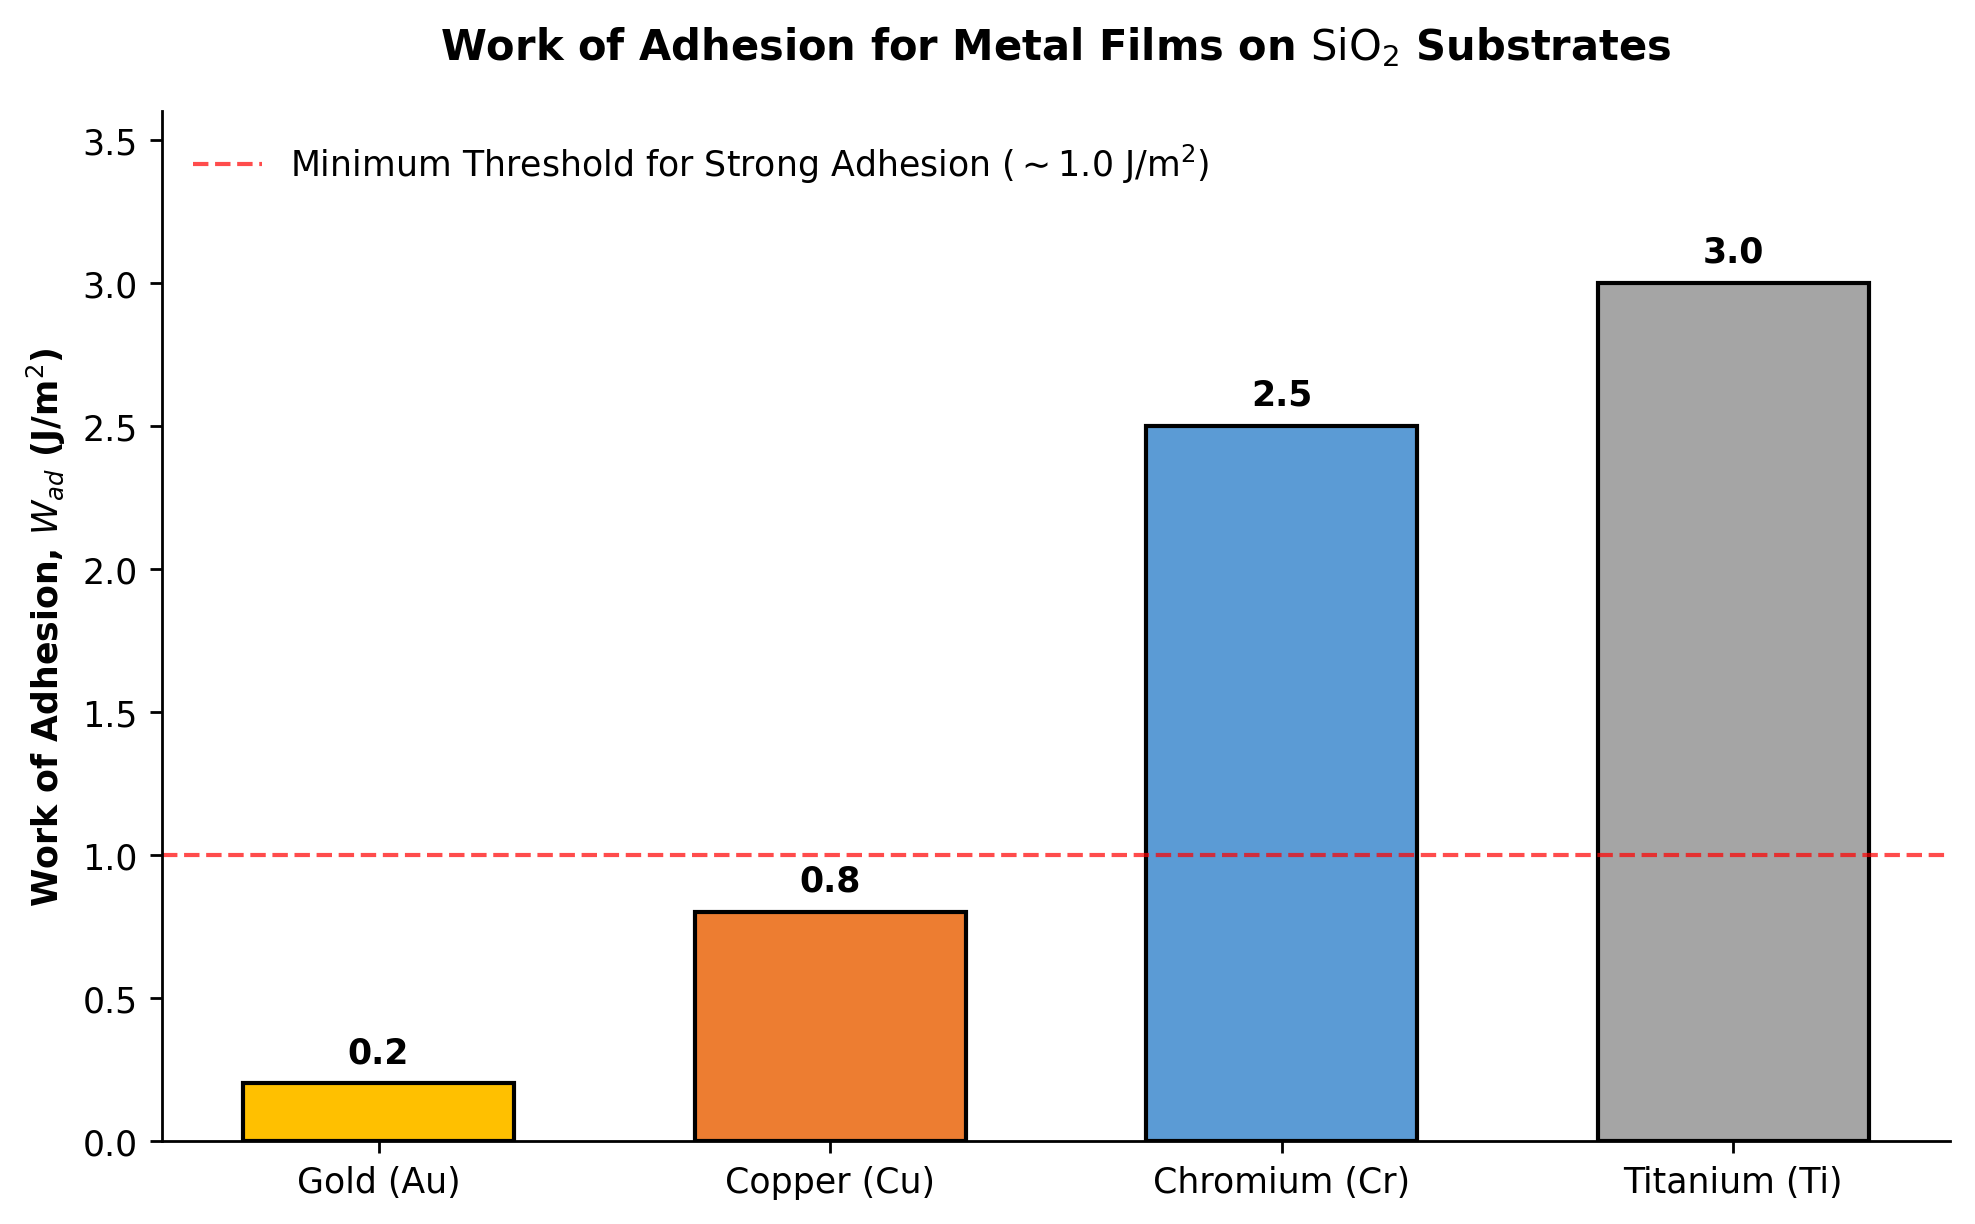

In [4]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films.

This module plots the Work of Adhesion (W_ad) for various metals
on a silicon dioxide substrate to demonstrate the necessity of
reactive adhesion layers (like Ti or Cr) for noble metal deposition.
"""

import matplotlib.pyplot as plt
import numpy as np


def plot_work_of_adhesion() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a SiO2 substrate.

    The plot is optimized for inline Colab rendering at 250 DPI.
    Data represents typical empirical values (J/m^2) derived from
    sessile drop contact angle measurements and the Young-Dupré equation.
    """
    # Configure resolution for Colab inline rendering
    plt.rcParams['figure.dpi'] = 250
    plt.rcParams['font.size'] = 10

    # Metal films on SiO2
    labels = [
        'Gold (Au)',
        'Copper (Cu)',
        'Chromium (Cr)',
        'Titanium (Ti)'
    ]

    # Approximate Work of Adhesion (W_ad) in J/m^2
    # Au: ~0.2, Cu: ~0.8, Cr: ~2.5, Ti: ~3.0
    w_ad_values = np.array([0.2, 0.8, 2.5, 3.0])

    # Color scheme: Noble (weak adhesion) -> Transition (strong adhesion)
    colors = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot bars
    bars = ax.bar(
        labels,
        w_ad_values,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        width=0.6
    )

    # Define a threshold line for "good" practical thin-film adhesion
    adhesion_threshold = 1.0
    ax.axhline(
        adhesion_threshold,
        color='red',
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=r'Minimum Threshold for Strong Adhesion ($\sim 1.0$ J/m$^2$)'
    )

    # Formatting and labels
    ax.set_ylabel(r'Work of Adhesion, $W_{ad}$ (J/m$^2$)', fontweight='bold')
    ax.set_title(
        'Work of Adhesion for Metal Films on $\\text{SiO}_2$ Substrates',
        fontweight='bold',
        pad=15
    )

    # Set y-axis limits to provide headroom for labels
    ax.set_ylim(0, max(w_ad_values) * 1.2)

    # Annotate values on the bars
    for bar, w_ad in zip(bars, w_ad_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    # Aesthetic tweaks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()

    # Render inline, explicitly avoiding plt.savefig for Colab compatibility
    plt.show()


if __name__ == '__main__':
    plot_work_of_adhesion()